**Mount Drive**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Import Libraries**

In [3]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Display Settings
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


**Load Dataset**

In [4]:
# Load Dataset

file_path = "/content/drive/MyDrive/Churn/Churn.csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


**Initial Data Inspection**

In [5]:
# Dataset Shape

print("Rows and Columns:")
print(df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

Rows and Columns:
(7043, 21)

First 5 Rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [8]:
df.columns.tolist()
df.shape

(7043, 21)

**Data Cleaning**

In [11]:
# Check Missing Values

print(df.isnull().sum())
print(df['TotalCharges'].dtype)
# Convert TotalCharges to numeric

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
object


**Check Missing Values Again and Remove Missing Rows**

In [14]:
print(df.isnull().sum())
df.dropna(inplace=True)
print(df.shape)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
(7032, 21)


**Exploratory Data Analysis**

Customer Churn Distribution

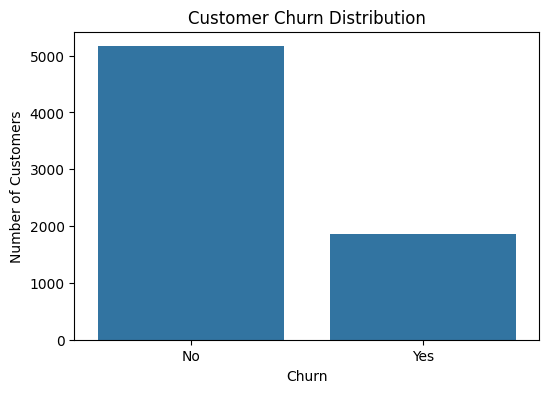

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

Business Interpretation

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


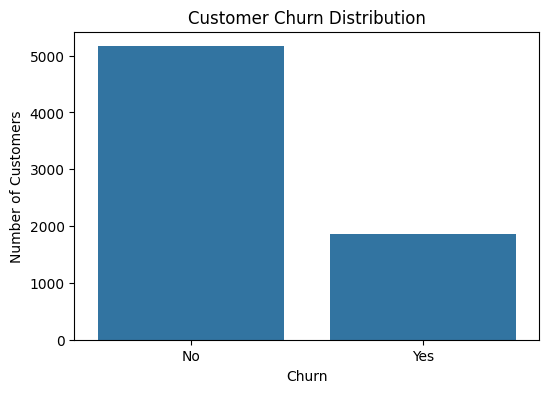

In [21]:
churn_percentage = df['Churn'].value_counts(normalize=True) * 100

print(churn_percentage)
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.savefig('fig1_churn_distribution.png',
            bbox_inches='tight',
            dpi=300)

plt.show()

Contract Type vs Churn

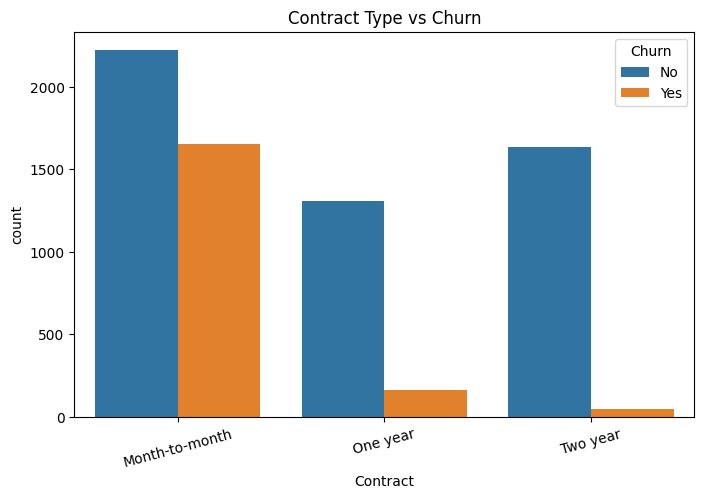

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.title('Contract Type vs Churn')
plt.xticks(rotation=15)

plt.show()

Tenure vs Churn

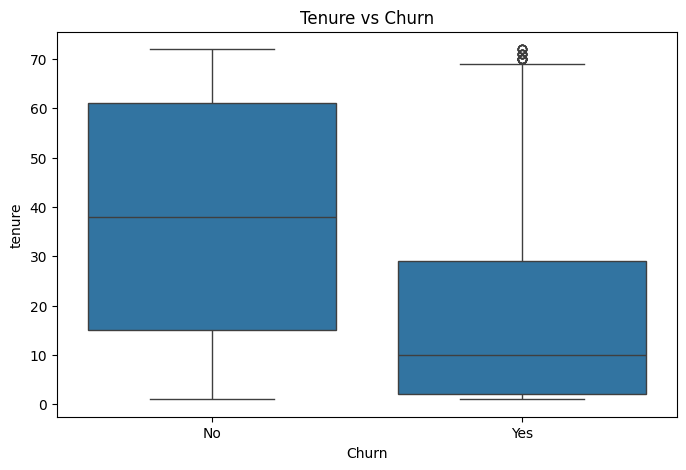

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='tenure',
    data=df
)

plt.title('Tenure vs Churn')

plt.savefig(
    'fig3_tenure_vs_churn.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

Monthly Charges vs Churn

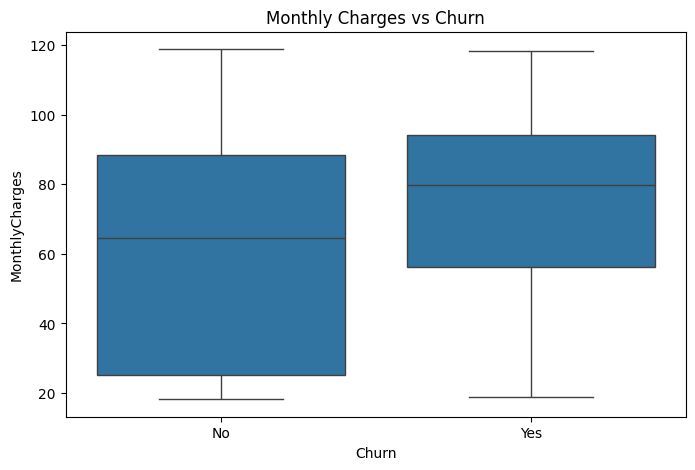

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title('Monthly Charges vs Churn')

plt.savefig(
    'fig4_monthly_charges_vs_churn.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

**Feature Engineering**

In [25]:
# Create modelling dataset

df_model = df.copy()

# One-Hot Encoding
df_model = pd.get_dummies(
    df_model,
    drop_first=True
)

print(df_model.shape)

df_model.head()

(7032, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True


**Train-Test Split**

In [29]:
# Features and Target
X = df_model.drop('Churn_Yes', axis=1)
y = df_model['Churn_Yes']

# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (5625, 30)
Testing Set: (1407, 30)


**Feature Scaling**

In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling Complete")

Scaling Complete


**Logistic Regression Model**

In [31]:
lr_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr_model.fit(
    X_train_scaled,
    y_train
)

print("Model Trained Successfully")

Model Trained Successfully


**Predictions**

In [32]:
y_pred_lr = lr_model.predict(X_test_scaled)

**Evaluations**

In [33]:
print("Accuracy:")

print(
    accuracy_score(
        y_test,
        y_pred_lr
    )
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

Accuracy:
0.8038379530916845

Classification Report:
              precision    recall  f1-score   support

       False       0.85      0.89      0.87      1033
        True       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



**Confusion Matrix**

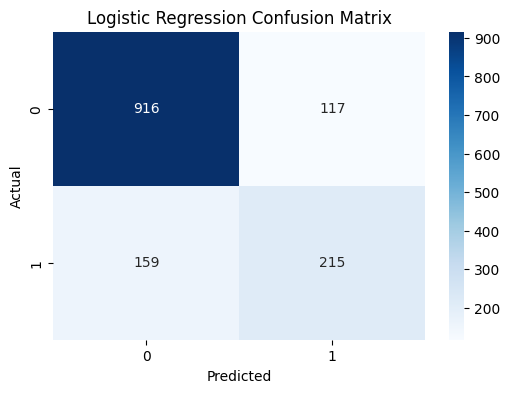

In [34]:
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Logistic Regression Confusion Matrix'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.savefig(
    'fig5_logistic_confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

**Decision Tree Classifier**

In [35]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

print("Decision Tree Trained Successfully")

Decision Tree Trained Successfully


**Predictions & Evaluations**

In [36]:
y_pred_dt = dt_model.predict(X_test)
print("Accuracy:")

print(
    accuracy_score(
        y_test,
        y_pred_dt
    )
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_dt
    )
)

Accuracy:
0.7782515991471215

Classification Report:
              precision    recall  f1-score   support

       False       0.85      0.84      0.85      1033
        True       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



**Confusion Matrix**

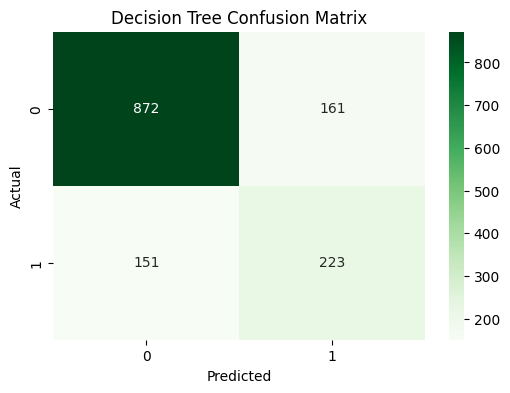

In [37]:
cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    'Decision Tree Confusion Matrix'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.savefig(
    'fig6_decision_tree_confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

**Feature Importance**

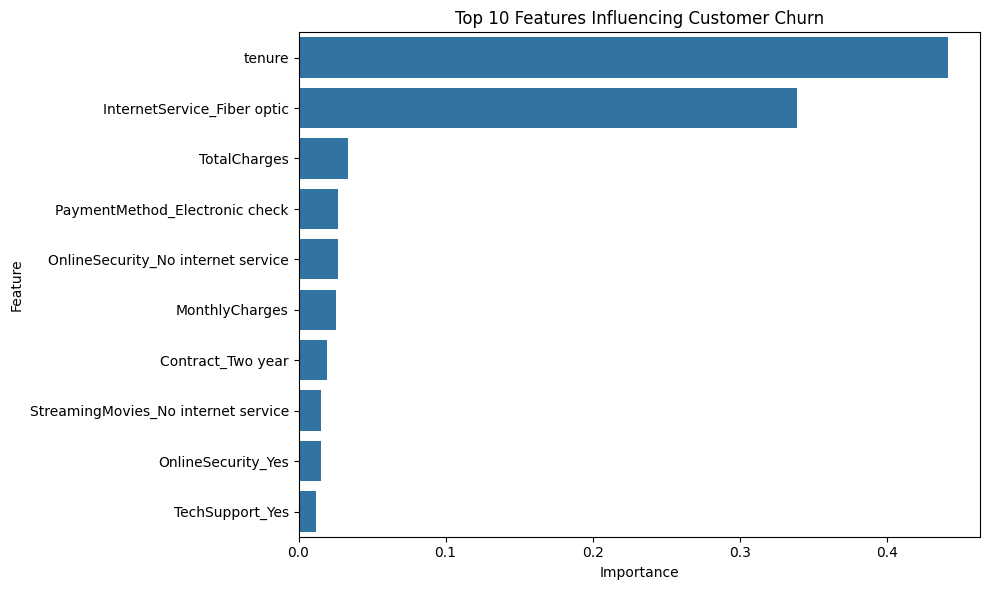

In [38]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title('Top 10 Features Influencing Customer Churn')

plt.tight_layout()

plt.savefig(
    'fig7_feature_importance.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

**ROC -AUC**

In [39]:
from sklearn.metrics import roc_auc_score

y_prob_lr = lr_model.predict_proba(X_test_scaled)[:,1]

auc = roc_auc_score(y_test, y_prob_lr)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.8356727976766699
